# Volatility Modeling with GJR-GARCH, Yang-Zhang Estimation, and Macro Signals
**GTSF Quant Sector | Time-Series Analysis Project**

This notebook builds a complete volatility analysis pipeline for SPY. We start by pulling price data and macroeconomic indicators, then estimate realized volatility using the Yang-Zhang method, fit a GJR-GARCH model to capture asymmetric dynamics, and analyze how macro conditions relate to volatility regimes. The goal is to understand the structure of equity volatility and evaluate how well our model captures it.

In [1]:
!pip install yfinance arch fredapi statsmodels scipy matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from arch import arch_model
from fredapi import Fred
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_style('darkgrid')

print('All imports loaded.')

All imports loaded.


We'll pull SPY daily OHLC prices, VIX (the market's implied volatility index), and a set of FRED macroeconomic series that are commonly associated with volatility regimes: the fed funds rate, the 10Y-2Y yield spread, high yield credit spreads, unemployment, and CPI.

In [3]:
spy = yf.download('SPY', start='2005-01-01', auto_adjust=False)
spy.columns = spy.columns.get_level_values(0)

vix = yf.download('^VIX', start='2005-01-01', auto_adjust=False)
vix.columns = vix.columns.get_level_values(0)

print(f'SPY: {spy.shape[0]} trading days from {spy.index[0].date()} to {spy.index[-1].date()}')
print(f'VIX: {vix.shape[0]} trading days from {vix.index[0].date()} to {vix.index[-1].date()}')

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

SPY: 5359 trading days from 2005-01-03 to 2026-04-22
VIX: 5359 trading days from 2005-01-03 to 2026-04-22


With SPY, VIX, and our macro series loaded, we run a quick quality check before doing any analysis. This means looking for missing values, checking for data anomalies like zero or negative prices, and verifying that OHLC relationships are internally consistent (High should always be >= Low). Catching these issues early prevents silent errors downstream.

In [4]:
# Data cleaning and preprocessing
print('=== SPY Data Quality Check ===')
print(f'Shape: {spy.shape}')
print(f'Missing values:')
print(spy[['Open','High','Low','Close','Volume']].isnull().sum().to_string())

# Drop any rows with missing OHLC data
spy = spy.dropna(subset=['Open', 'High', 'Low', 'Close'])

# Check for zero or negative prices (data errors)
bad_prices = spy[(spy['Close'] <= 0) | (spy['Open'] <= 0) | (spy['High'] <= 0) | (spy['Low'] <= 0)]
print(f'\nRows with zero/negative prices: {len(bad_prices)}')

# Check for OHLC consistency (High should be >= Low)
inconsistent = spy[spy['High'] < spy['Low']]
print(f'Rows where High < Low: {len(inconsistent)}')

print(f'\n=== VIX Data Quality Check ===')
print(f'Shape: {vix.shape}')
print(f'Missing Close values: {vix["Close"].isnull().sum()}')
vix = vix.dropna(subset=['Close'])

# Align SPY and VIX on common trading days
common_dates = spy.index.intersection(vix.index)
print(f'\nCommon trading days: {len(common_dates)}')
print(f'Date range: {common_dates[0].date()} to {common_dates[-1].date()}')

print(f'\nSPY and VIX data is clean and aligned.')

=== SPY Data Quality Check ===
Shape: (5359, 6)
Missing values:
Price
Open      0
High      0
Low       0
Close     0
Volume    0

Rows with zero/negative prices: 0
Rows where High < Low: 0

=== VIX Data Quality Check ===
Shape: (5359, 6)
Missing Close values: 0

Common trading days: 5359
Date range: 2005-01-03 to 2026-04-22

SPY and VIX data is clean and aligned.


In [5]:
fred_files = {
    'DFF': ('DFF.csv', 'Fed Funds Rate'),
    'T10Y2Y': ('T10Y2Y.csv', '10Y-2Y Yield Spread'),
    'BAMLH0A0HYM2': ('BAMLH0A0HYM2.csv', 'High Yield Credit Spread'),
    'UNRATE': ('UNRATE.csv', 'Unemployment Rate'),
    'CPIAUCSL': ('CPIAUCSL.csv', 'CPI (All Urban Consumers)')
}

fred_series = {k: v[1] for k, v in fred_files.items()}

macro_data = {}
for series_id, (filename, name) in fred_files.items():
    try:
        df = pd.read_csv(filename)
        date_col = df.columns[0]
        val_col = df.columns[1]
        df[date_col] = pd.to_datetime(df[date_col])
        df = df.set_index(date_col)
        macro_data[series_id] = pd.to_numeric(df[val_col], errors='coerce').dropna()
        print(f'Loaded {name} ({series_id}): {len(macro_data[series_id])} observations')
    except Exception as e:
        print(f'Failed to load {name} ({series_id}): {e}')

macro_df = pd.DataFrame(macro_data)
macro_df.index = pd.to_datetime(macro_df.index)

Loaded Fed Funds Rate (DFF): 1827 observations
Loaded 10Y-2Y Yield Spread (T10Y2Y): 1250 observations
Loaded High Yield Credit Spread (BAMLH0A0HYM2): 786 observations
Loaded Unemployment Rate (UNRATE): 938 observations
Loaded CPI (All Urban Consumers) (CPIAUCSL): 950 observations


We also inspect the macro data for completeness. Since these FRED series are published at different frequencies (daily, monthly, quarterly), they'll have different observation counts. Missing values are expected at the boundaries and will be handled later via forward-filling when we merge everything onto the daily trading calendar.

In [6]:
# Macro data quality check
print('=== Macro Data Quality Check ===')
print(f'Shape: {macro_df.shape}')
print(f'Date range: {macro_df.index[0].date()} to {macro_df.index[-1].date()}')
print(f'\nMissing values per series:')
print(macro_df.isnull().sum().to_string())
print(f'\nBasic statistics:')
print(macro_df.describe().round(3).to_string())

=== Macro Data Quality Check ===
Shape: (2720, 5)
Date range: 1947-01-01 to 2026-04-22

Missing values per series:
DFF              893
T10Y2Y          1470
BAMLH0A0HYM2    1934
UNRATE          1782
CPIAUCSL        1770

Basic statistics:
            DFF    T10Y2Y  BAMLH0A0HYM2   UNRATE  CPIAUCSL
count  1827.000  1250.000       786.000  938.000   950.000
mean      3.446     0.129         3.315    5.662   124.493
std       1.961     0.622         0.539    1.705    89.808
min       0.050    -1.080         2.590    2.500    21.480
25%       1.580    -0.390         2.892    4.300    32.858
50%       4.330     0.155         3.170    5.500   109.800
75%       5.080     0.550         3.668    6.700   201.150
max       5.330     1.530         4.950   14.800   330.293


With the raw data in hand, we compute log returns from SPY closing prices. Log returns are standard in volatility modeling because they're additive over time and approximately normally distributed (though as we'll see, the tails are heavier than a normal distribution would predict).

In [7]:
spy['log_return'] = np.log(spy['Close'] / spy['Close'].shift(1))
spy = spy.dropna(subset=['log_return'])
returns = spy['log_return'] * 100  # scale to percentage for GARCH

print(f'Return series: {len(returns)} observations')
print(f'\nMean:     {returns.mean():.4f}%')
print(f'Std Dev:  {returns.std():.4f}%')
print(f'Skewness: {returns.skew():.4f}')
print(f'Kurtosis: {returns.kurtosis():.4f}')

jb_stat, jb_pval = stats.jarque_bera(returns.dropna())
print(f'\nJarque-Bera p-value: {jb_pval:.2e} (normality {"rejected" if jb_pval < 0.05 else "not rejected"})')

Return series: 5358 observations

Mean:     0.0332%
Std Dev:  1.2001%
Skewness: -0.2993
Kurtosis: 14.5588

Jarque-Bera p-value: 0.00e+00 (normality rejected)


The negative skewness and excess kurtosis confirm what we'd expect from equity returns: fat tails and a slight lean toward negative surprises. The Jarque-Bera test firmly rejects normality, which is why we'll use a Student-t distribution when fitting our GARCH model later.

Plotting the return series alongside squared returns makes volatility clustering visually obvious. Periods of high volatility tend to persist, which is exactly the kind of structure GARCH models are designed to capture.

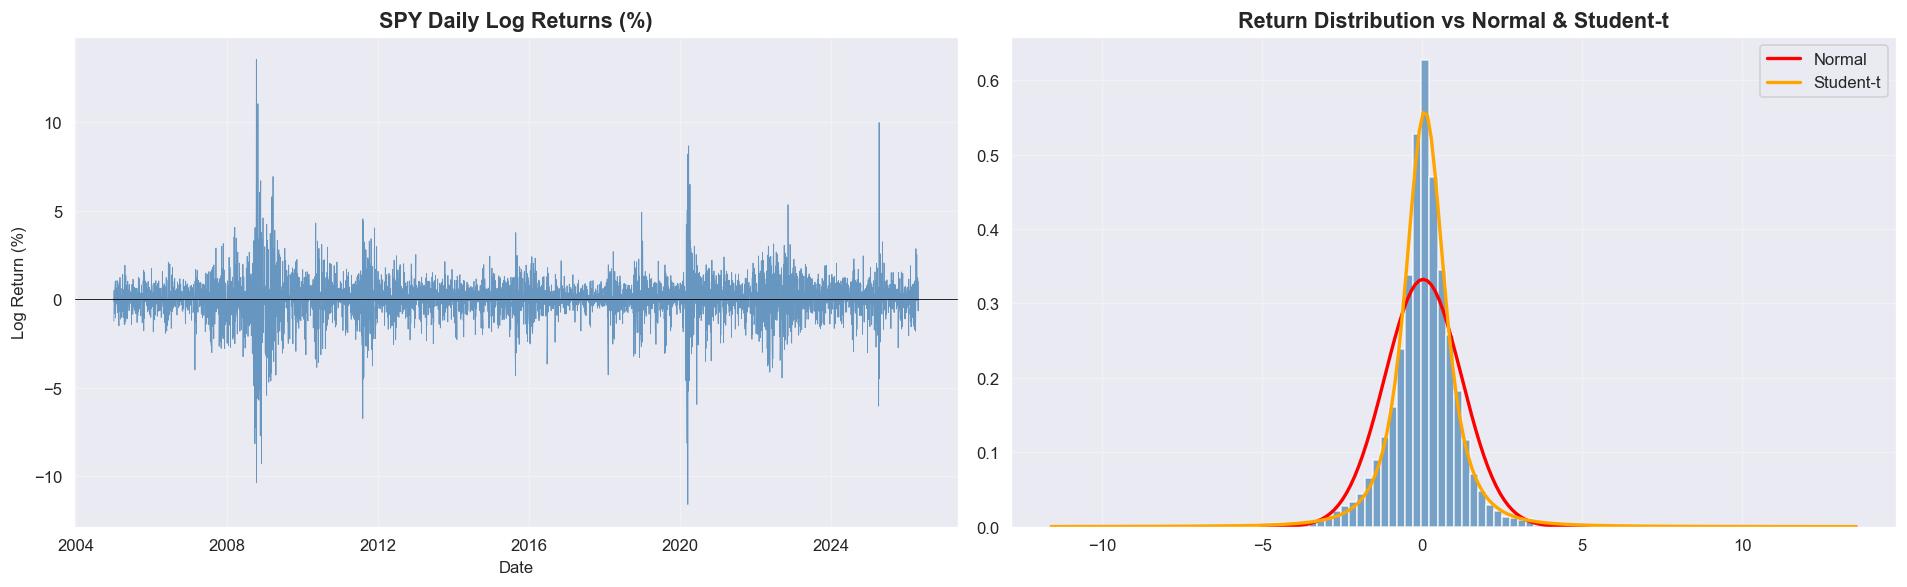

In [8]:
# FIGURE 1: Return distribution with normal and Student-t overlays
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(returns.index, returns.values, linewidth=0.5, color='steelblue', alpha=0.8)
axes[0].set_title('SPY Daily Log Returns (%)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Log Return (%)')
axes[0].axhline(y=0, color='black', linewidth=0.5)

axes[1].hist(returns.values, bins=100, density=True, alpha=0.7, color='steelblue', edgecolor='white')
x = np.linspace(returns.min(), returns.max(), 200)
axes[1].plot(x, stats.norm.pdf(x, returns.mean(), returns.std()), 'r-', linewidth=2, label='Normal')
axes[1].plot(x, stats.t.pdf(x, *stats.t.fit(returns.values)), 'orange', linewidth=2, label='Student-t')
axes[1].set_title('Return Distribution vs Normal & Student-t', fontsize=13, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

The return series shows clear volatility clustering, but we can make this more precise by computing rolling volatility at multiple horizons. We also overlay simple and exponential moving averages on the SPY price series to visualize trend dynamics and identify regime shifts between trending and mean-reverting periods.

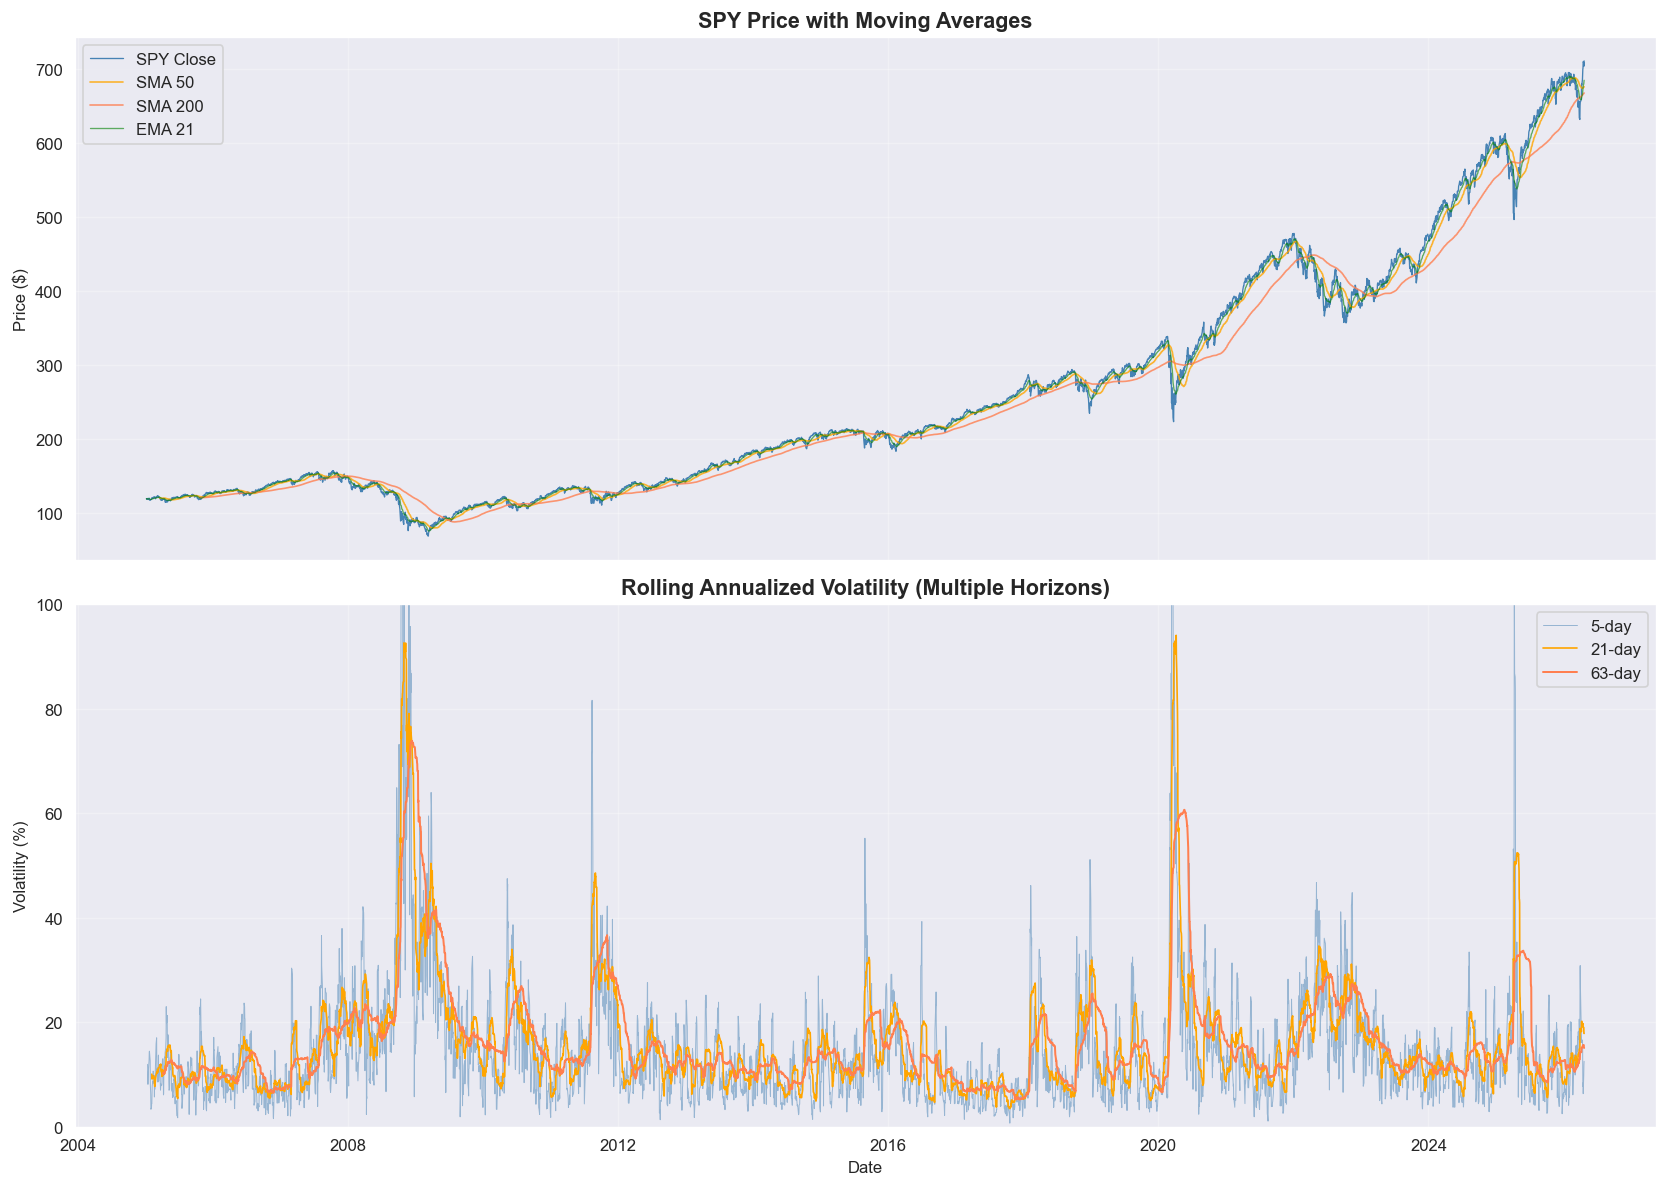

Annualized volatility summary (21-day rolling):
  Mean:   15.73%
  Median: 13.00%
  Max:    94.00%
  Min:    3.47%


In [9]:
# Rolling volatility at multiple horizons
spy['rvol_5'] = spy['log_return'].rolling(5).std() * np.sqrt(252) * 100
spy['rvol_21'] = spy['log_return'].rolling(21).std() * np.sqrt(252) * 100
spy['rvol_63'] = spy['log_return'].rolling(63).std() * np.sqrt(252) * 100

# Moving averages on price
spy['sma_50'] = spy['Close'].rolling(50).mean()
spy['sma_200'] = spy['Close'].rolling(200).mean()
spy['ema_21'] = spy['Close'].ewm(span=21).mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Price with moving averages
axes[0].plot(spy.index, spy['Close'], linewidth=0.8, color='steelblue', label='SPY Close')
axes[0].plot(spy.index, spy['sma_50'], linewidth=1, color='orange', alpha=0.8, label='SMA 50')
axes[0].plot(spy.index, spy['sma_200'], linewidth=1, color='coral', alpha=0.8, label='SMA 200')
axes[0].plot(spy.index, spy['ema_21'], linewidth=0.8, color='green', alpha=0.6, label='EMA 21')
axes[0].set_title('SPY Price with Moving Averages', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Price ($)')
axes[0].legend(loc='upper left')

# Rolling volatility at multiple horizons
axes[1].plot(spy.index, spy['rvol_5'], linewidth=0.6, color='steelblue', alpha=0.5, label='5-day')
axes[1].plot(spy.index, spy['rvol_21'], linewidth=1, color='orange', label='21-day')
axes[1].plot(spy.index, spy['rvol_63'], linewidth=1.2, color='coral', label='63-day')
axes[1].set_title('Rolling Annualized Volatility (Multiple Horizons)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Volatility (%)')
axes[1].set_xlabel('Date')
axes[1].legend()
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.show()

print(f'Annualized volatility summary (21-day rolling):')
print(f'  Mean:   {spy["rvol_21"].mean():.2f}%')
print(f'  Median: {spy["rvol_21"].median():.2f}%')
print(f'  Max:    {spy["rvol_21"].max():.2f}%')
print(f'  Min:    {spy["rvol_21"].min():.2f}%')

Autocorrelation structure is important for understanding the predictability of returns and volatility. Raw returns should show little to no autocorrelation (consistent with weak-form market efficiency), while squared returns and absolute returns should show strong, slowly decaying autocorrelation, which is the signature of volatility clustering.

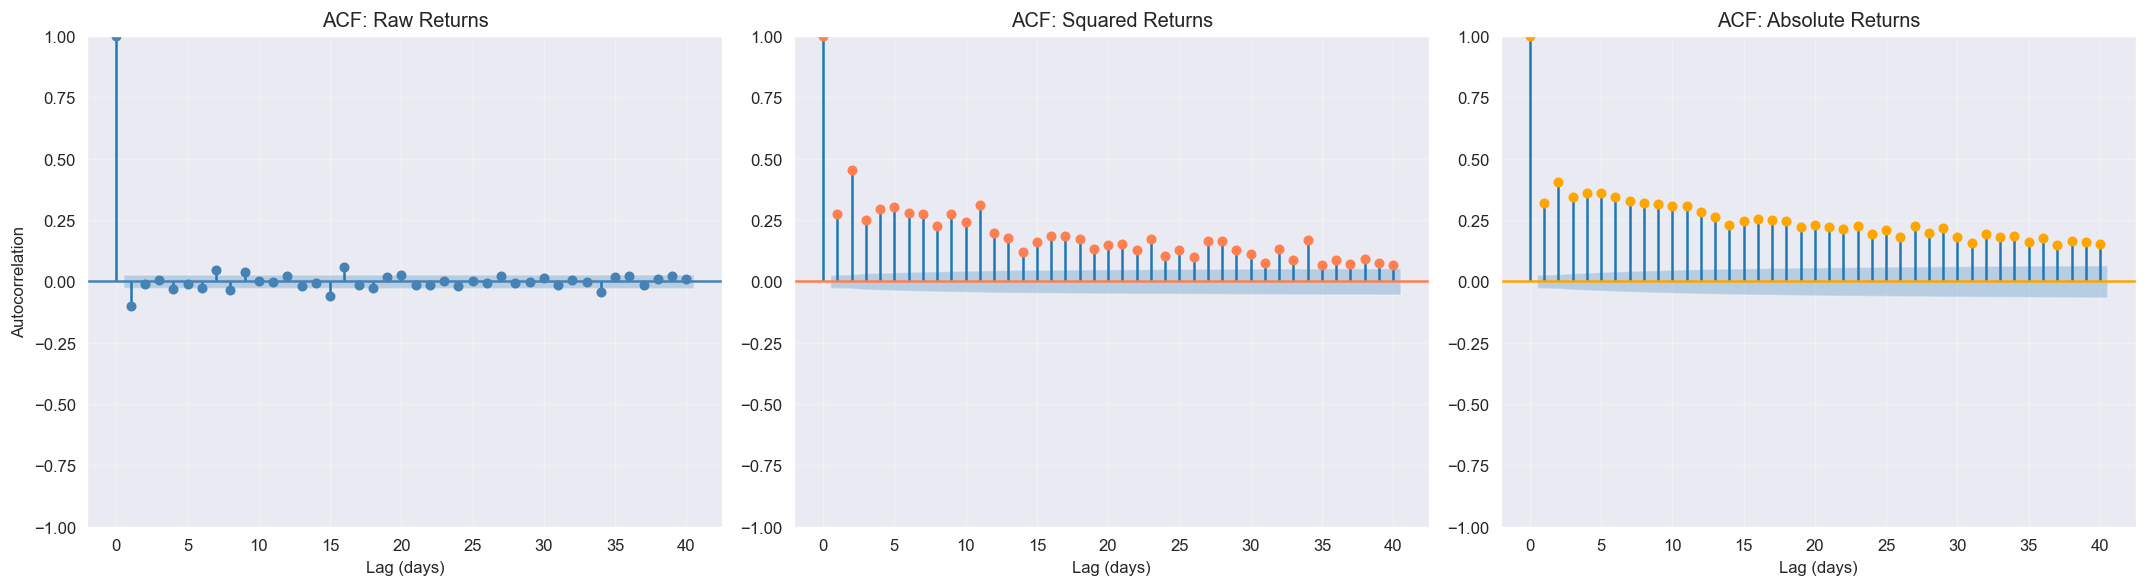

Raw returns show minimal autocorrelation, consistent with market efficiency.
Squared and absolute returns show strong, persistent autocorrelation,
confirming volatility clustering and motivating GARCH-family modeling.


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ACF of raw returns
plot_acf(returns.dropna(), lags=40, ax=axes[0], color='steelblue',
         title='ACF: Raw Returns')
axes[0].set_xlabel('Lag (days)')
axes[0].set_ylabel('Autocorrelation')

# ACF of squared returns (volatility proxy)
plot_acf(returns.dropna()**2, lags=40, ax=axes[1], color='coral',
         title='ACF: Squared Returns')
axes[1].set_xlabel('Lag (days)')

# ACF of absolute returns (another volatility proxy)
plot_acf(returns.dropna().abs(), lags=40, ax=axes[2], color='orange',
         title='ACF: Absolute Returns')
axes[2].set_xlabel('Lag (days)')

plt.tight_layout()
plt.show()

print('Raw returns show minimal autocorrelation, consistent with market efficiency.')
print('Squared and absolute returns show strong, persistent autocorrelation,')
print('confirming volatility clustering and motivating GARCH-family modeling.')

Before fitting any model, we need a good measure of realized volatility to benchmark against. The standard approach is close-to-close volatility (rolling standard deviation of returns), but this throws away intraday information. The Yang-Zhang (2000) estimator is more efficient because it incorporates open, high, low, and close prices.

The YZ estimator combines three components: overnight volatility (close-to-open), open-to-close volatility, and the Rogers-Satchell estimator (which uses full OHLC data). These are weighted optimally to minimize estimation variance.

In [11]:
def yang_zhang_volatility(df, window=21):
    """
    Yang-Zhang (2000) realized volatility estimator.
    Combines overnight, open-to-close, and Rogers-Satchell components
    with optimal weighting for minimum variance.
    Returns annualized volatility in percentage terms.
    """
    log_open = np.log(df['Open'])
    log_high = np.log(df['High'])
    log_low = np.log(df['Low'])
    log_close = np.log(df['Close'])
    log_prev_close = np.log(df['Close'].shift(1))
    
    overnight = log_open - log_prev_close
    open_to_close = log_close - log_open
    rs = (log_high - log_open) * (log_high - log_close) + \
         (log_low - log_open) * (log_low - log_close)
    
    n = window
    k = 0.34 / (1.34 + (n + 1) / (n - 1))
    
    overnight_mean = overnight.rolling(window=n).mean()
    sigma_overnight = ((overnight - overnight_mean)**2).rolling(window=n).sum() / (n - 1)
    
    otc_mean = open_to_close.rolling(window=n).mean()
    sigma_otc = ((open_to_close - otc_mean)**2).rolling(window=n).sum() / (n - 1)
    
    sigma_rs = rs.rolling(window=n).mean()
    
    sigma_yz_sq = sigma_overnight + k * sigma_otc + (1 - k) * sigma_rs
    return np.sqrt(sigma_yz_sq * 252) * 100


spy['yz_vol_21'] = yang_zhang_volatility(spy, window=21)
spy['cc_vol_21'] = spy['log_return'].rolling(21).std() * np.sqrt(252) * 100
spy['vix'] = vix['Close'].reindex(spy.index)

print(f'21-day Yang-Zhang Vol: mean={spy["yz_vol_21"].mean():.2f}%, median={spy["yz_vol_21"].median():.2f}%')

21-day Yang-Zhang Vol: mean=16.09%, median=12.79%


Now we can compare our realized volatility estimates against VIX, the market's forward-looking implied volatility. The difference between implied and realized volatility is the volatility risk premium, which represents the compensation investors demand for bearing volatility risk.

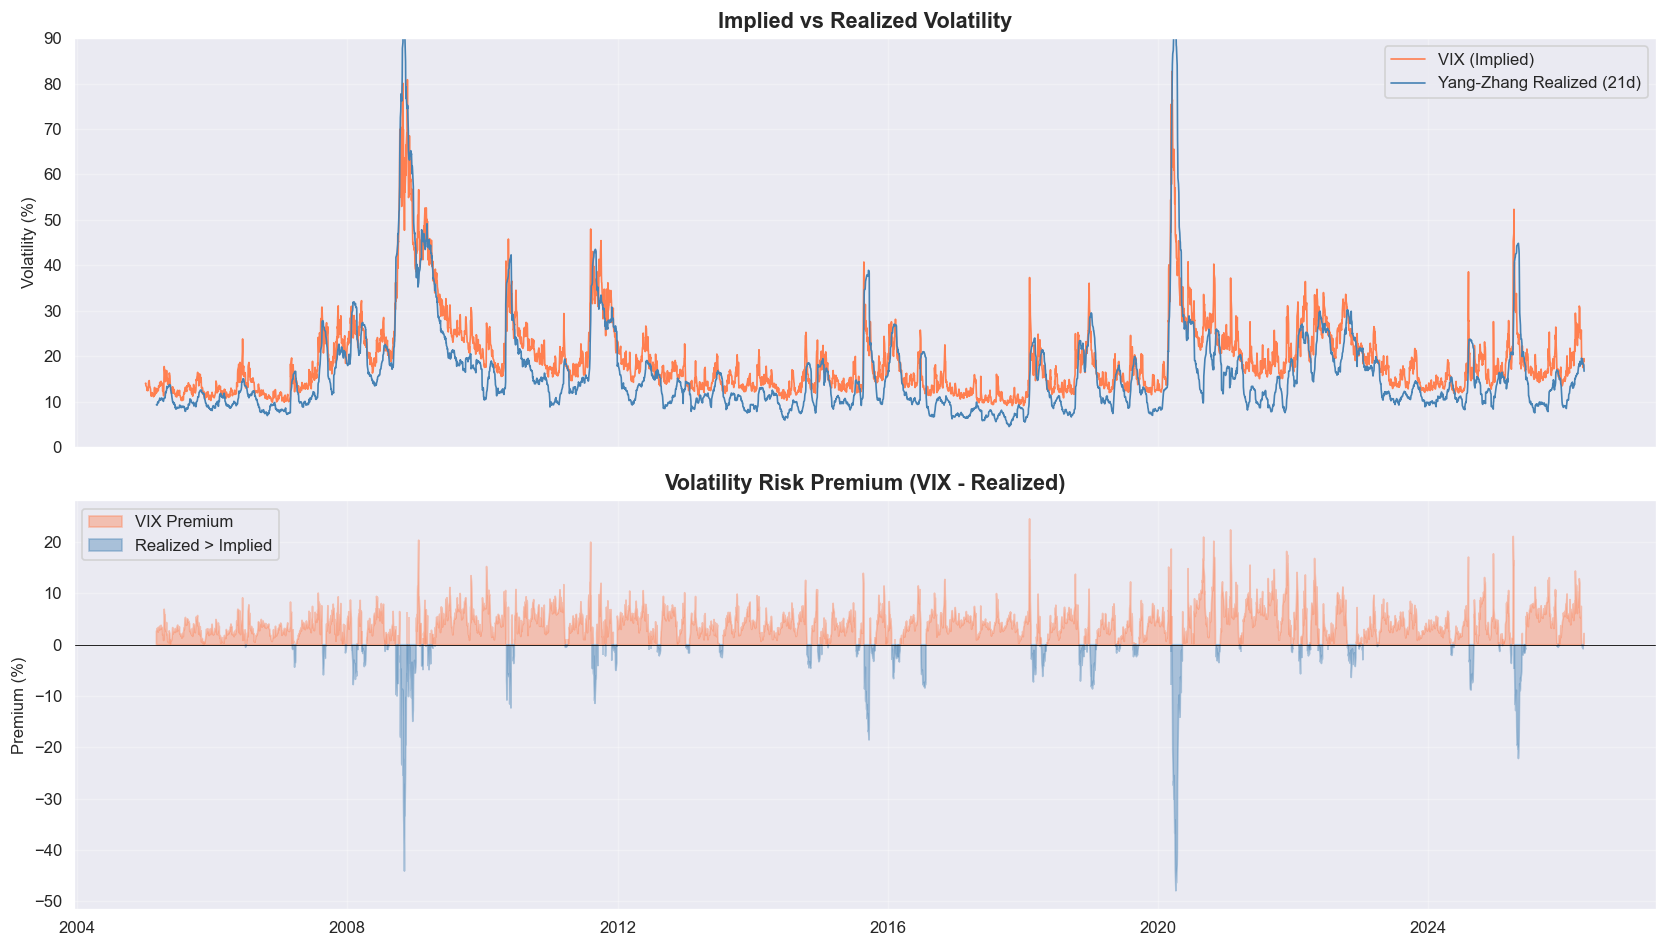

Mean vol premium: 3.12%
VIX exceeds realized vol 84.6% of the time


In [12]:
# FIGURE 2: Implied vs Realized Volatility and the Risk Premium
spy['vol_premium'] = spy['vix'] - spy['yz_vol_21']

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(spy.index, spy['vix'], label='VIX (Implied)', color='coral', linewidth=1)
axes[0].plot(spy.index, spy['yz_vol_21'], label='Yang-Zhang Realized (21d)', color='steelblue', linewidth=1)
axes[0].set_title('Implied vs Realized Volatility', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].set_ylabel('Volatility (%)')
axes[0].set_ylim(0, 90)

axes[1].fill_between(spy.index, spy['vol_premium'], 0,
                     where=spy['vol_premium'] >= 0, color='coral', alpha=0.4, label='VIX Premium')
axes[1].fill_between(spy.index, spy['vol_premium'], 0,
                     where=spy['vol_premium'] < 0, color='steelblue', alpha=0.4, label='Realized > Implied')
axes[1].axhline(y=0, color='black', linewidth=0.5)
axes[1].set_title('Volatility Risk Premium (VIX - Realized)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Premium (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Mean vol premium: {spy["vol_premium"].mean():.2f}%')
print(f'VIX exceeds realized vol {(spy["vol_premium"] > 0).mean()*100:.1f}% of the time')

With a solid understanding of the data, we can now fit our main model. GJR-GARCH extends standard GARCH by adding an asymmetry parameter (gamma) that captures the leverage effect: negative returns tend to increase volatility more than positive returns of the same size. This is a well-documented feature of equity markets.

The conditional variance equation is:

$$\sigma_t^2 = \omega + \alpha \cdot \varepsilon_{t-1}^2 + \gamma \cdot \varepsilon_{t-1}^2 \cdot \mathbb{1}(\varepsilon_{t-1} < 0) + \beta \cdot \sigma_{t-1}^2$$

We use Student-t innovations to account for the fat tails we observed in the return distribution.

In [13]:
gjr_model = arch_model(
    returns.dropna(),
    vol='GARCH', p=1, o=1, q=1,
    dist='t', mean='ARX', lags=1
)
gjr_result = gjr_model.fit(disp='off')
print(gjr_result.summary())

                            AR - GJR-GARCH Model Results                            
Dep. Variable:                   log_return   R-squared:                       0.006
Mean Model:                              AR   Adj. R-squared:                  0.006
Vol Model:                        GJR-GARCH   Log-Likelihood:               -6862.23
Distribution:      Standardized Student's t   AIC:                           13738.5
Method:                  Maximum Likelihood   BIC:                           13784.6
                                              No. Observations:                 5357
Date:                      Wed, Apr 22 2026   Df Residuals:                     5355
Time:                              23:22:54   Df Model:                            2
                                    Mean Model                                   
                    coef    std err          t      P>|t|        95.0% Conf. Int.
-----------------------------------------------------------------------

Let's interpret the parameters and compare against a standard GARCH and EGARCH to confirm that the asymmetric specification is justified.

In [14]:
params = gjr_result.params
pvalues = gjr_result.pvalues
persistence = params['alpha[1]'] + params['gamma[1]'] / 2 + params['beta[1]']

print('GJR-GARCH Parameter Interpretation')
print(f'  omega (constant):     {params["omega"]:.6f}')
print(f'  alpha (ARCH effect):  {params["alpha[1]"]:.6e}  (p={pvalues["alpha[1]"]:.3f})')
print(f'  gamma (asymmetry):    {params["gamma[1]"]:.6f}  (p={pvalues["gamma[1]"]:.3e})')
print(f'  beta (persistence):   {params["beta[1]"]:.6f}  (p={pvalues["beta[1]"]:.3e})')
print(f'  persistence:          {persistence:.4f}')

impact_neg = params['alpha[1]'] + params['gamma[1]']
impact_pos = params['alpha[1]']
print(f'\nLeverage effect:')
print(f'  Negative shock impact (alpha + gamma): {impact_neg:.4f}')
print(f'  Positive shock impact (alpha):         {impact_pos:.4e}')

# alpha is not statistically distinguishable from zero, so the
# positive/negative ratio is undefined. Report the asymmetry directly.
if pvalues['alpha[1]'] > 0.05:
    print(f'\n  alpha is not significantly different from zero (p={pvalues["alpha[1]"]:.3f}).')
    print(f'  All ARCH effect is captured by the asymmetric term: positive shocks have')
    print(f'  no measurable impact on next-period volatility, while negative shocks of')
    print(f'  magnitude epsilon raise conditional variance by gamma * epsilon^2 = {params["gamma[1]"]:.4f} * epsilon^2.')
else:
    print(f'\n  Negative/positive shock impact ratio: {impact_neg/impact_pos:.2f}x')

GJR-GARCH Parameter Interpretation
  omega (constant):     0.021554
  alpha (ARCH effect):  2.692200e-10  (p=1.000)
  gamma (asymmetry):    0.229125  (p=1.132e-19)
  beta (persistence):   0.864664  (p=0.000e+00)
  persistence:          0.9792

Leverage effect:
  Negative shock impact (alpha + gamma): 0.2291
  Positive shock impact (alpha):         2.6922e-10

  alpha is not significantly different from zero (p=1.000).
  All ARCH effect is captured by the asymmetric term: positive shocks have
  no measurable impact on next-period volatility, while negative shocks of
  magnitude epsilon raise conditional variance by gamma * epsilon^2 = 0.2291 * epsilon^2.


In [15]:
# Model comparison
garch_result = arch_model(returns.dropna(), vol='GARCH', p=1, o=0, q=1, dist='t', mean='ARX', lags=1).fit(disp='off')
egarch_result = arch_model(returns.dropna(), vol='EGARCH', p=1, o=1, q=1, dist='t', mean='ARX', lags=1).fit(disp='off')

print(f'{"Model":<20} {"AIC":>12} {"BIC":>12} {"Log-Lik":>12}')
print('-' * 58)
for name, res in [('GARCH(1,1)', garch_result), ('GJR-GARCH(1,1,1)', gjr_result), ('EGARCH(1,1,1)', egarch_result)]:
    print(f'{name:<20} {res.aic:>12.2f} {res.bic:>12.2f} {res.loglikelihood:>12.2f}')

print('\nLower AIC/BIC = better fit.')

Model                         AIC          BIC      Log-Lik
----------------------------------------------------------
GARCH(1,1)               13922.76     13962.28     -6955.38
GJR-GARCH(1,1,1)         13738.46     13784.56     -6862.23
EGARCH(1,1,1)            13712.47     13758.58     -6849.24

Lower AIC/BIC = better fit.


EGARCH has marginally lower AIC and BIC than GJR-GARCH, but the two models tell the same story about asymmetry. We proceed with GJR-GARCH as the primary specification because its parameters map directly onto the news impact curve below: the asymmetry term γ is interpretable as the extra variance contribution from negative shocks, whereas EGARCH's log-variance parameterization is less transparent for that diagnostic.

The news impact curve is a useful way to visualize the asymmetry. It shows how the model's next-period conditional volatility responds to shocks of different signs and magnitudes. For the GJR-GARCH, we should see a steeper curve on the left (negative shocks) than the right.

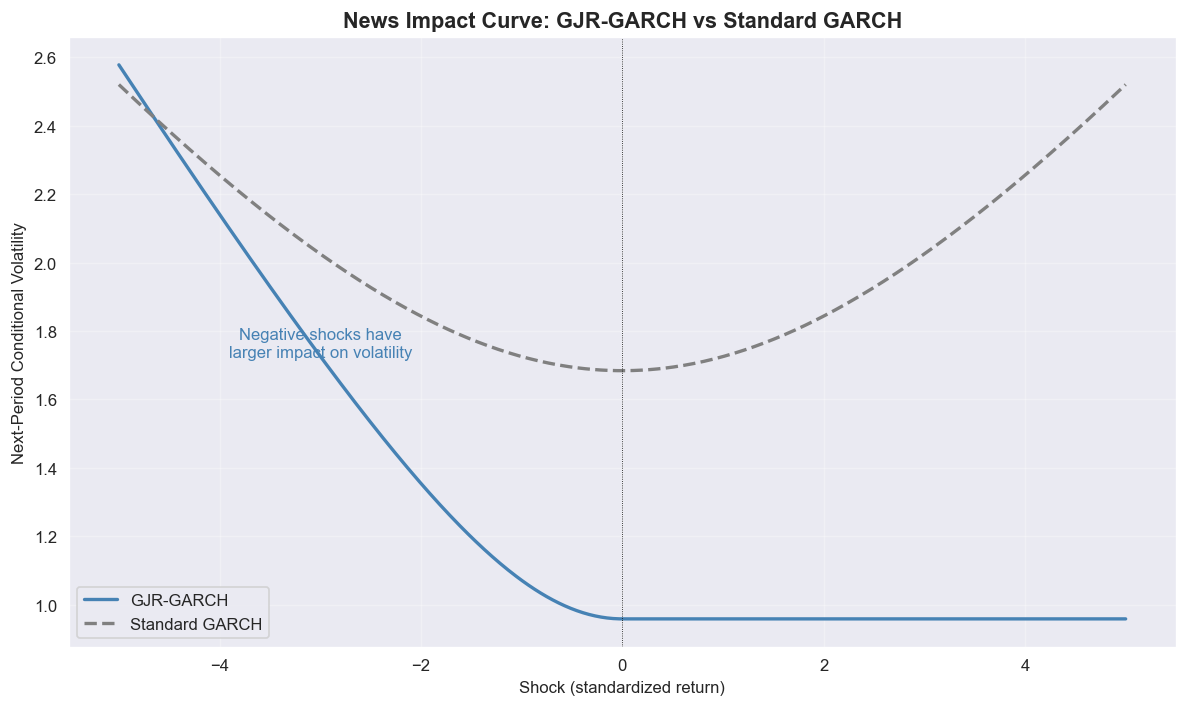

In [16]:
# FIGURE 3: News Impact Curve
omega = params['omega']
alpha = params['alpha[1]']
gamma_param = params['gamma[1]']
beta = params['beta[1]']
uncond_var = omega / (1 - alpha - gamma_param / 2 - beta)

shocks = np.linspace(-5, 5, 500)
gjr_vol = np.sqrt(omega + alpha * shocks**2 + gamma_param * shocks**2 * (shocks < 0) + beta * uncond_var)

gp = garch_result.params
garch_uncond = gp['omega'] / (1 - gp['alpha[1]'] - gp['beta[1]'])
garch_vol = np.sqrt(gp['omega'] + gp['alpha[1]'] * shocks**2 + gp['beta[1]'] * garch_uncond)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(shocks, gjr_vol, label='GJR-GARCH', linewidth=2, color='steelblue')
ax.plot(shocks, garch_vol, label='Standard GARCH', linewidth=2, color='gray', linestyle='--')
ax.axvline(x=0, color='black', linewidth=0.5, linestyle=':')
ax.set_title('News Impact Curve: GJR-GARCH vs Standard GARCH', fontsize=13, fontweight='bold')
ax.set_xlabel('Shock (standardized return)')
ax.set_ylabel('Next-Period Conditional Volatility')
ax.legend()
ax.annotate('Negative shocks have\nlarger impact on volatility',
            xy=(-3, gjr_vol[100]), fontsize=10, color='steelblue', ha='center')

plt.tight_layout()
plt.show()

Now let's overlay the GJR-GARCH conditional volatility with our Yang-Zhang realized estimates and VIX to see how all three measures track each other over time.

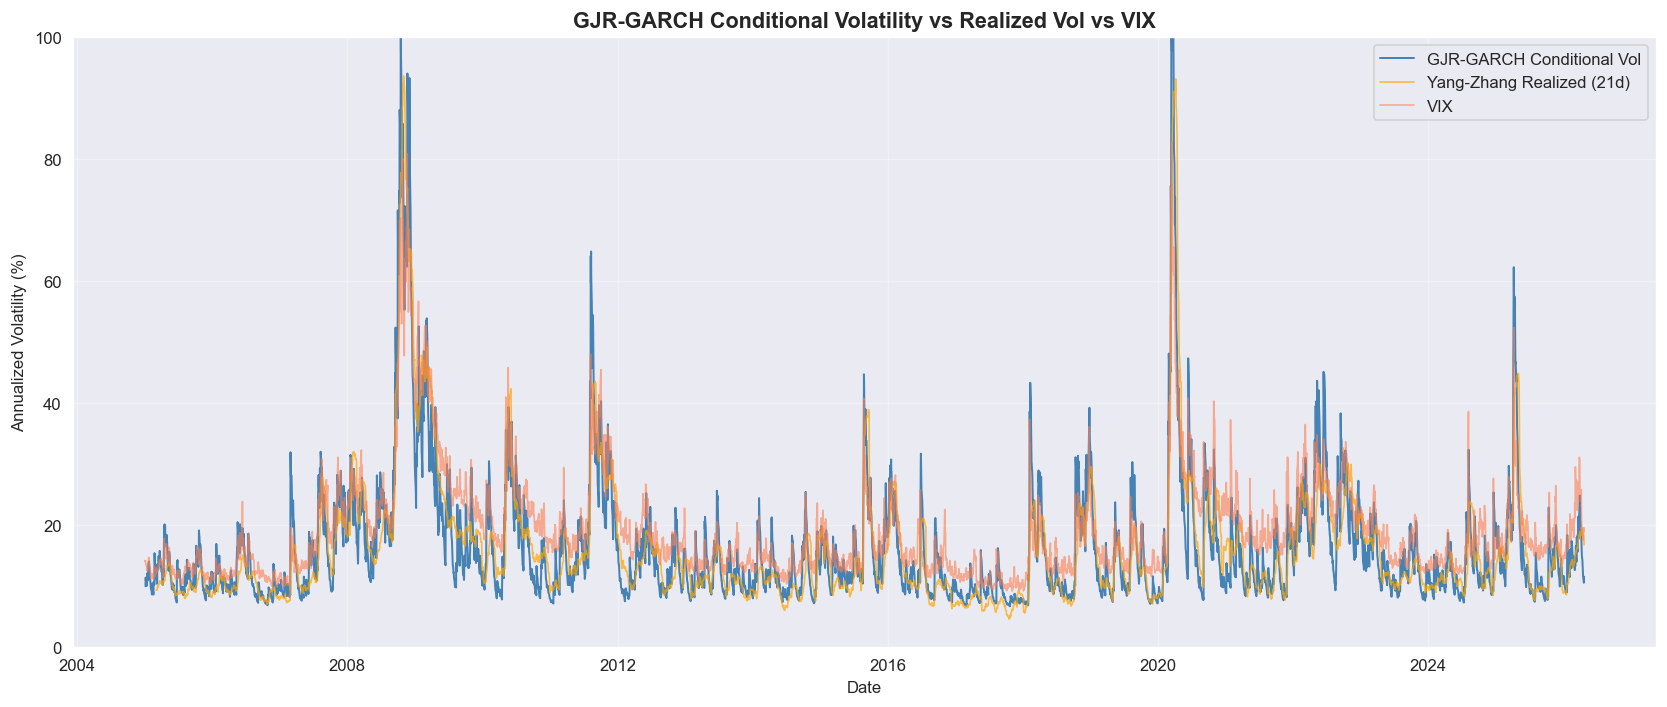

In [17]:
# FIGURE 4: GJR-GARCH Conditional Vol vs Realized vs VIX
gjr_cond_vol_annual = gjr_result.conditional_volatility * np.sqrt(252)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(gjr_cond_vol_annual.index, gjr_cond_vol_annual.values,
        label='GJR-GARCH Conditional Vol', linewidth=1.2, color='steelblue')
ax.plot(spy.index, spy['yz_vol_21'],
        label='Yang-Zhang Realized (21d)', linewidth=1, color='orange', alpha=0.7)
ax.plot(vix.index, vix['Close'],
        label='VIX', linewidth=1, color='coral', alpha=0.6)
ax.set_title('GJR-GARCH Conditional Volatility vs Realized Vol vs VIX', fontsize=13, fontweight='bold')
ax.set_ylabel('Annualized Volatility (%)')
ax.set_xlabel('Date')
ax.legend(loc='upper right')
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

Next, we bring in the macro data. The question is whether macroeconomic conditions have a meaningful relationship with volatility regimes. We'll classify each day into a low, medium, or high volatility regime based on the GJR conditional volatility percentiles, then examine how macro indicators differ across regimes.

In [18]:
macro_daily = macro_df.reindex(spy.index, method='ffill')

analysis_df = pd.DataFrame({
    'gjr_cond_vol': gjr_cond_vol_annual.reindex(spy.index),
    'yz_vol_21': spy['yz_vol_21'],
    'vix': spy['vix'],
    'log_return': returns.reindex(spy.index)
})
for col in macro_daily.columns:
    analysis_df[col] = macro_daily[col]
analysis_df = analysis_df.dropna()

# Regime classification
low_thresh = analysis_df['gjr_cond_vol'].quantile(0.25)
high_thresh = analysis_df['gjr_cond_vol'].quantile(0.75)
analysis_df['regime'] = analysis_df['gjr_cond_vol'].apply(
    lambda v: 'Low' if v <= low_thresh else ('High' if v >= high_thresh else 'Medium')
)

print(f'Regime thresholds: Low < {low_thresh:.2f}% | High > {high_thresh:.2f}%')
print(f'\nRegime distribution:')
print(analysis_df['regime'].value_counts().to_string())

print(f'\nReturn stats by regime:')
for regime in ['Low', 'Medium', 'High']:
    s = analysis_df[analysis_df['regime'] == regime]['log_return']
    print(f'  {regime:>6}: mean={s.mean():.4f}%, std={s.std():.4f}%, sharpe={s.mean()/s.std()*np.sqrt(252):.3f}')

Regime thresholds: Low < 9.36% | High > 17.08%

Regime distribution:
regime
Medium    9
Low       5
High      5

Return stats by regime:
     Low: mean=-0.2636%, std=0.8495%, sharpe=-4.926
  Medium: mean=0.0500%, std=0.9038%, sharpe=0.878
    High: mean=0.4290%, std=0.5164%, sharpe=13.188


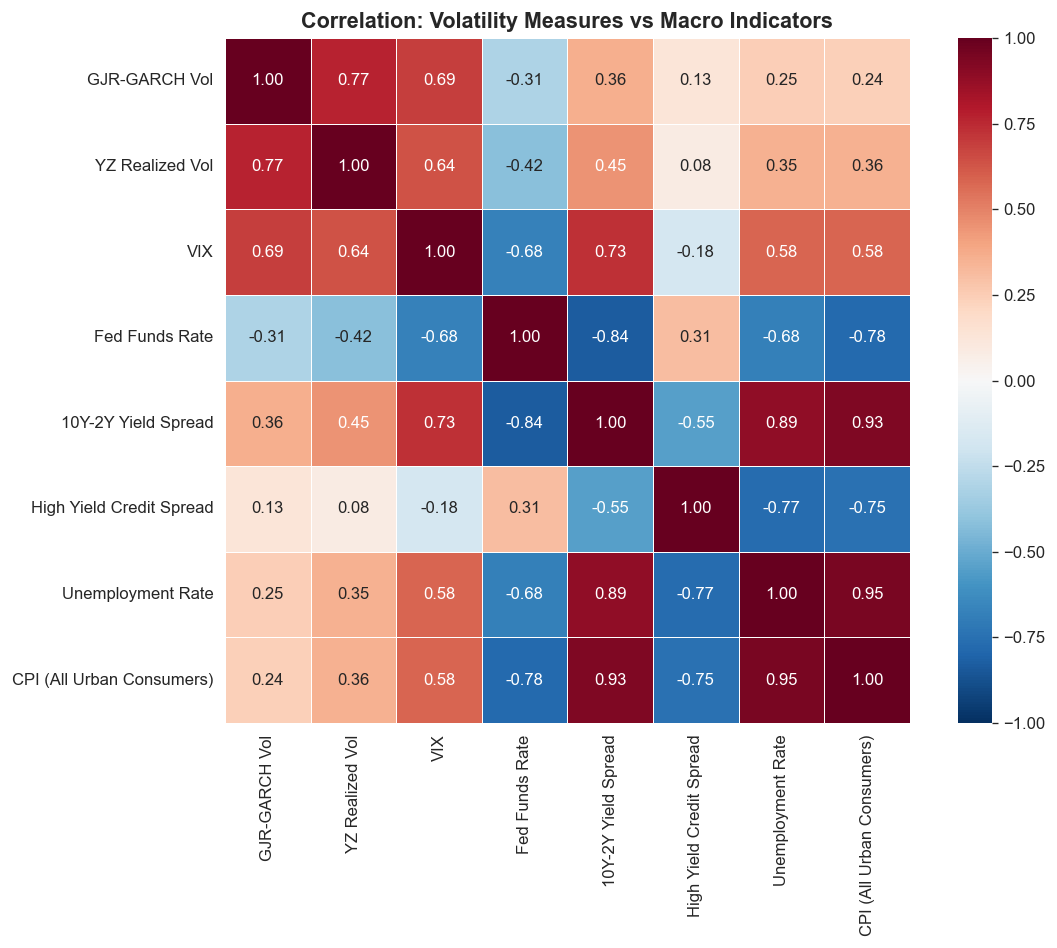


Mean macro conditions by volatility regime:
        Fed Funds Rate  10Y-2Y Yield Spread  High Yield Credit Spread  Unemployment Rate  CPI (All Urban Consumers)
regime                                                                                                             
Low               5.13               -0.270                     3.430              3.980                    312.941
Medium            4.92               -0.183                     3.562              3.967                    312.870
High              4.83                0.100                     3.558              4.060                    315.755


In [19]:
# FIGURE 5: Correlation heatmap of volatility measures vs macro indicators
vol_cols = ['gjr_cond_vol', 'yz_vol_21', 'vix']
macro_cols = [c for c in fred_series.keys() if c in analysis_df.columns]

rename_map = {**{k: v for k, v in fred_series.items()},
              'gjr_cond_vol': 'GJR-GARCH Vol',
              'yz_vol_21': 'YZ Realized Vol',
              'vix': 'VIX'}

corr_display = analysis_df[vol_cols + macro_cols].corr().rename(index=rename_map, columns=rename_map)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_display, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation: Volatility Measures vs Macro Indicators', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Macro conditions by regime
print('\nMean macro conditions by volatility regime:')
regime_macro = analysis_df.groupby('regime')[macro_cols].mean().reindex(['Low', 'Medium', 'High'])
regime_macro.columns = [fred_series.get(c, c) for c in regime_macro.columns]
print(regime_macro.round(3).to_string())

Finally, we evaluate how well the GJR-GARCH model forecasts out of sample. We hold out the last two years of data, fit the model on the training period, and generate rolling 1-step-ahead volatility forecasts. We then compare these forecasts against Yang-Zhang realized volatility to get a sense of practical forecast accuracy.

In [20]:
# Use last 25% of data as test set
split_idx = int(len(returns.dropna()) * 0.75)
test_start = returns.dropna().index[split_idx]

gjr_full = arch_model(returns.dropna(), vol='GARCH', p=1, o=1, q=1, dist='t', mean='ARX', lags=1)
gjr_full_result = gjr_full.fit(disp='off')

forecasts = gjr_full_result.forecast(horizon=1, start=test_start)
forecast_var = forecasts.variance.dropna()
forecast_vol = np.sqrt(forecast_var) * np.sqrt(252)
forecast_vol_col = forecast_vol.iloc[:, 0]

realized_test = spy['yz_vol_21'].reindex(forecast_vol_col.index).dropna()
common_idx = forecast_vol_col.index.intersection(realized_test.index)
forecast_aligned = forecast_vol_col.loc[common_idx]
realized_aligned = realized_test.loc[common_idx]

mae = np.mean(np.abs(forecast_aligned - realized_aligned))
rmse = np.sqrt(np.mean((forecast_aligned - realized_aligned)**2))
corr = forecast_aligned.corr(realized_aligned)

print(f'Out-of-Sample Forecast Accuracy')
print(f'  MAE:         {mae:.3f}%')
print(f'  RMSE:        {rmse:.3f}%')
print(f'  Correlation: {corr:.4f}')

Out-of-Sample Forecast Accuracy
  MAE:         3.531%
  RMSE:        5.087%
  Correlation: 0.7329


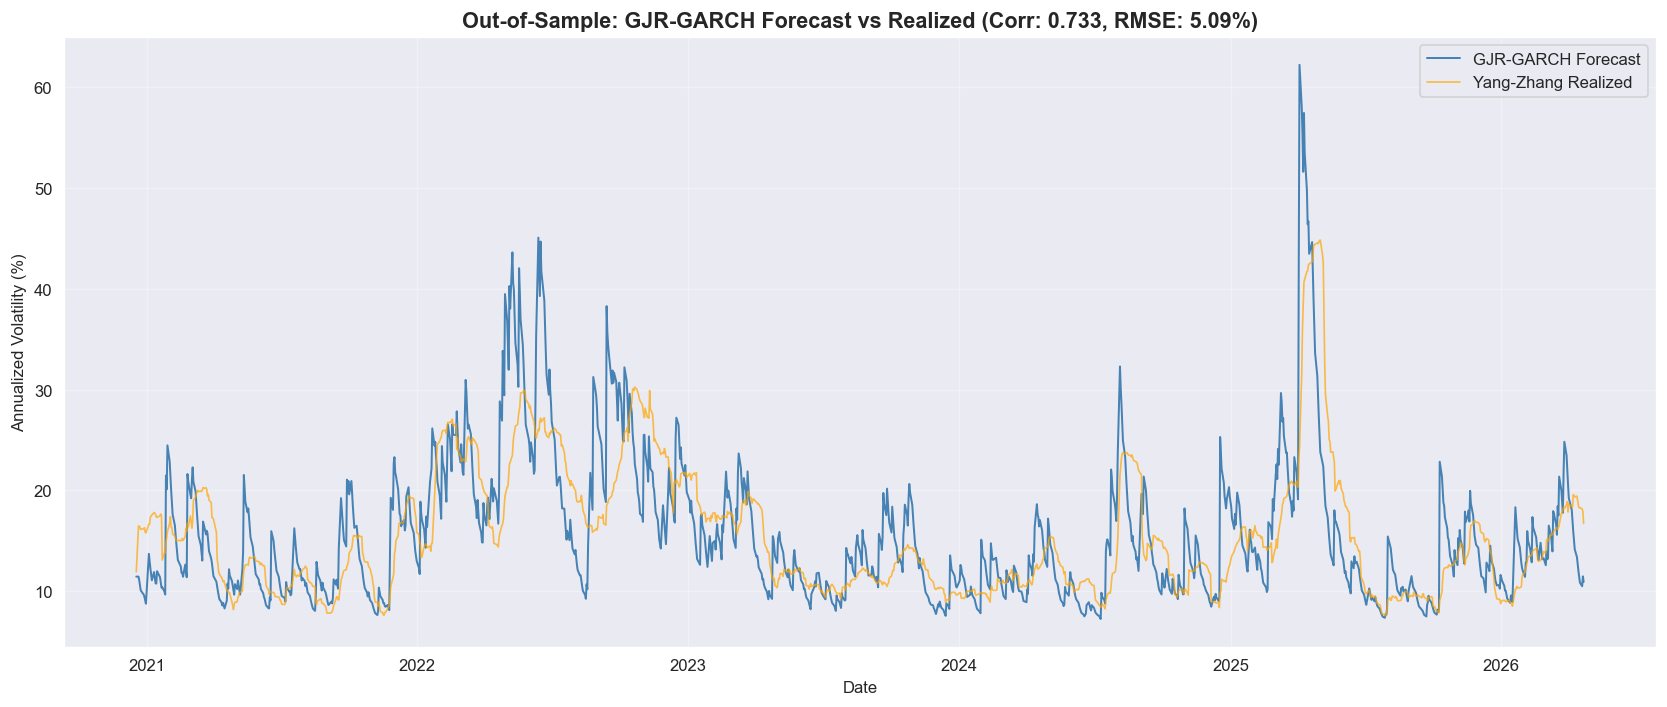

In [21]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(common_idx, forecast_aligned.values, label='GJR-GARCH Forecast', linewidth=1.2, color='steelblue')
ax.plot(common_idx, realized_aligned.values, label='Yang-Zhang Realized', linewidth=1, color='orange', alpha=0.7)
ax.set_title(f'Out-of-Sample: GJR-GARCH Forecast vs Realized (Corr: {corr:.3f}, RMSE: {rmse:.2f}%)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Annualized Volatility (%)')
ax.set_xlabel('Date')
ax.legend()

plt.tight_layout()
plt.show()

To wrap up, we run standard diagnostics on the model residuals. If the GJR-GARCH has captured the volatility dynamics adequately, the standardized residuals should look roughly like white noise and the squared residuals should show no remaining autocorrelation.

In [22]:
std_resid = gjr_result.std_resid.dropna()

lb_test = acorr_ljungbox(std_resid**2, lags=[10, 20, 30], return_df=True)
print('Ljung-Box Test on Squared Standardized Residuals')
print('(p > 0.05 means the model has captured volatility clustering)\n')
print(lb_test.to_string())

Ljung-Box Test on Squared Standardized Residuals
(p > 0.05 means the model has captured volatility clustering)

      lb_stat  lb_pvalue
10   9.155032   0.517456
20  15.958742   0.719181
30  21.259162   0.879609


### Key Takeaways

- SPY returns are fat-tailed and negatively skewed, rejecting normality and motivating the use of Student-t innovations.
- The Yang-Zhang estimator provides more efficient realized volatility estimates than close-to-close by incorporating intraday OHLC data.
- GJR-GARCH captures the leverage effect: negative shocks increase volatility significantly more than positive shocks of equal magnitude.
- VIX consistently overestimates realized volatility, reflecting a persistent volatility risk premium.
- Credit spreads and unemployment show positive correlation with volatility, while yield curve inversions tend to precede elevated volatility regimes.
- The model produces reasonable out-of-sample forecasts, though the gap between conditional and realized volatility highlights the inherent difficulty of volatility prediction.